# Appendix C in code: 2D elasticity and the fourth Pauli component

Companion notebook to *Structured Block Encoding of the Finite Element
Elasticity Operator*, Appendix C. Run notebooks A and B first.

Elasticity adds the displacement components. Each node now carries $u_x$ and
$u_y$, so the operator has a $2\times2$ block structure that a single extra
qubit absorbs. The rewriting is

$$\mathbf{K} = \frac{\mathbf{K}_{xx}+\mathbf{K}_{yy}}{2}\otimes I
             + \frac{\mathbf{K}_{xx}-\mathbf{K}_{yy}}{2}\otimes Z
             + \mathbf{K}_{xy}\otimes X,$$

three **Pauli components**, each an $N^2\times N^2$ spatial block tensored with
one Pauli matrix. The same nine shift offsets as 2D Poisson now carry three
components instead of one, giving $17$ terms rather than $9$.

The interesting part is Section 6. Opening the boundary destroys a symmetry
that the periodic and clamped operators quietly rely on, and a **fourth**
component $iY$ appears. This notebook watches that happen.

**Contents**

1. Setup and the three 1D factors
2. The DOF-qubit rewriting
3. The 17-term periodic LCU and $\alpha(\nu)$
4. Which component sits where in the stencil
5. Essential conditions: 17 $\to$ 49
6. Traction-free: the shear block loses its symmetry
7. The special value $\nu = 1/3$
8. Mixed conditions
9. The cantilever
10. How tight is $\alpha$ here?
11. The block encoding
12. Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True, linewidth=140)
m, N = 2, 4
nid = lambda ix, iy: ix * N + iy
print(f"{N}x{N} nodes, 2 displacement components, {2*N*N} degrees of freedom")

4x4 nodes, 2 displacement components, 32 degrees of freedom


## 1. Setup and the three 1D factors

Elasticity needs a third 1D factor beyond stiffness and mass: the gradient
$\mathbf{G}_1 = \mathbf{A}^\top$ with
$\mathbf{A}_{ij} = \int f_i' f_j\,dx$. It is antisymmetric on a periodic grid,
and that fact turns out to be load-bearing.

The free correction is $-\Pi_j$ for $\mathbf{K}_1$, $-\tfrac13\Pi_j$ for
$\mathbf{M}_1$, and $\mp\tfrac12\Pi_j$ for $\mathbf{G}_1$ — antisymmetric
across the two ends, which is why its identity terms cancel when both ends are
free and do **not** cancel when only one is.

In [2]:
def shift(N, k=1):
    S = np.zeros((N, N))
    for j in range(N): S[(j + k) % N, j] = 1.0
    return S

def refl(N, idx):
    R = np.eye(N)
    for j in np.atleast_1d(idx): R[j, j] = -1.0
    return R

I, Sc = np.eye(N), shift(N); Scd = Sc.T
R0, RN = refl(N, 0), refl(N, N - 1)
U = {"I": I, "Sc": Sc, "R0.Sc": R0 @ Sc, "Sc'": Scd, "RN.Sc'": RN @ Scd,
     "R0": R0, "RN": RN}
PAULI = {"I": np.eye(2), "Z": np.diag([1., -1.]),
         "X": np.array([[0., 1.], [1., 0.]]),
         "iY": np.array([[0., 1.], [-1., 0.]])}      # real, unitary, Hermitian term

def K1(fl=False, fr=False, per=False):
    if per: return {"I": 2.0, "Sc": -1.0, "Sc'": -1.0}
    d = defaultdict(float, {"I": 2.0, "Sc": -.5, "R0.Sc": -.5,
                            "Sc'": -.5, "RN.Sc'": -.5})
    if fl: d["I"] -= .5; d["R0"] += .5
    if fr: d["I"] -= .5; d["RN"] += .5
    return dict(d)

def M1(fl=False, fr=False, per=False):
    if per: return {"I": 4/6, "Sc": 1/6, "Sc'": 1/6}
    d = defaultdict(float, {"I": 4/6, "Sc": 1/12, "R0.Sc": 1/12,
                            "Sc'": 1/12, "RN.Sc'": 1/12})
    if fl: d["I"] -= 1/6; d["R0"] += 1/6
    if fr: d["I"] -= 1/6; d["RN"] += 1/6
    return dict(d)

def G1(fl=False, fr=False, per=False):
    if per: return {"Sc'": 0.5, "Sc": -0.5}
    d = defaultdict(float, {"Sc'": .25, "RN.Sc'": .25, "Sc": -.25, "R0.Sc": -.25})
    if fl: d["I"] -= .25; d["R0"] += .25          # -1/2 Pi_0
    if fr: d["I"] += .25; d["RN"] -= .25          # +1/2 Pi_{N-1}
    return dict(d)

d1 = lambda d: sum(c * U[k] for k, c in d.items())

for nm, kw in [("periodic", dict(per=True)), ("essential", {}),
               ("traction-free", dict(fl=True, fr=True))]:
    G = d1(G1(**kw))
    print(f"G_1 {nm:<15} antisymmetric? {np.allclose(G, -G.T)}")
    print(2 * G, "\n")

G_1 periodic        antisymmetric? True
[[ 0.  1.  0. -1.]
 [-1.  0.  1.  0.]
 [ 0. -1.  0.  1.]
 [ 1.  0. -1.  0.]] 

G_1 essential       antisymmetric? True
[[ 0.  1.  0.  0.]
 [-1.  0.  1.  0.]
 [ 0. -1.  0.  1.]
 [ 0.  0. -1.  0.]] 

G_1 traction-free   antisymmetric? False
[[-1.  1.  0.  0.]
 [-1.  0.  1.  0.]
 [ 0. -1.  0.  1.]
 [ 0.  0. -1.  1.]] 



$\mathbf{G}_1$ is antisymmetric in the periodic and essential forms. The
traction-free form is that antisymmetric matrix plus the boundary diagonal
$\tfrac12(-1,0,0,1)$ — and that diagonal is the whole story of Section 6.

## 2. The DOF-qubit rewriting

With separable shape functions the three blocks of the plane-stress operator
are, at $C = E/(1-\nu^2)$,

$$\mathbf{K}_{xx} = C\left[\mathbf{K}_1\!\otimes\!\mathbf{M}_1
   + \tfrac{1-\nu}{2}\mathbf{M}_1\!\otimes\!\mathbf{K}_1\right], \quad
  \mathbf{K}_{yy} = (x \leftrightarrow y), \quad
  \mathbf{K}_{xy} = C\left[\nu\,\mathbf{A}\!\otimes\!\mathbf{A}^\top
   + \tfrac{1-\nu}{2}\mathbf{A}^\top\!\otimes\!\mathbf{A}\right].$$

Rather than hard-code those, we build the LCU directly in the $\{I,Z,X,iY\}$
basis. Splitting $\mathbf{K}_{xy}$ into symmetric and antisymmetric parts and
using $|0\rangle\langle 1| = \tfrac12(X + iY)$ gives the general form; the
$iY$ coefficient carries the factor $(1-3\nu)/4$ and vanishes whenever
$\mathbf{K}_{xy}$ is symmetric.

In [3]:
BASIS = np.stack([U[k].reshape(-1) for k in U], 1)

def transpose_terms(d):
    """Express M^T over the same seven unitaries."""
    c, *_ = np.linalg.lstsq(BASIS, d1(d).T.reshape(-1), rcond=None)
    out = {k: v for k, v in zip(U, c) if abs(v) > 1e-12}
    assert np.abs(d1(out) - d1(d).T).max() < 1e-12, "M^T left the span"
    return out

def kt(a, b):
    o = defaultdict(float)
    for p, cp in a.items():
        for q, cq in b.items(): o[(p, q)] += cp * cq
    return o

def ax_(a, b, s=1.0):
    o = defaultdict(float, a)
    for k, v in b.items(): o[k] += s * v
    return o

def elasticity(nu, xf=(False, False), yf=(False, False), per=False, E=1.0):
    Cc = E / (1 - nu ** 2)
    Kx, Mx, Gx = K1(*xf, per=per), M1(*xf, per=per), G1(*xf, per=per)
    Ky, My, Gy = K1(*yf, per=per), M1(*yf, per=per), G1(*yf, per=per)
    Gxt, Gyt = transpose_terms(Gx), transpose_terms(Gy)
    KM, MK = kt(Kx, My), kt(Mx, Ky)
    cI, cZ = ax_(KM, MK), ax_(KM, MK, -1.0)
    GGt, GtG = kt(Gx, Gyt), kt(Gxt, Gy)
    t = defaultdict(float)
    for (p, q), v in cI.items():  t[(p, q, "I")]  += Cc * (3 - nu) / 4 * v
    for (p, q), v in cZ.items():  t[(p, q, "Z")]  += Cc * (1 + nu) / 4 * v
    for (p, q), v in GGt.items(): t[(p, q, "X")]  += Cc * (1 + nu) / 4 * v
    for (p, q), v in GtG.items(): t[(p, q, "X")]  += Cc * (1 + nu) / 4 * v
    for (p, q), v in GGt.items(): t[(p, q, "iY")] += Cc * (1 - 3*nu) / 4 * v
    for (p, q), v in GtG.items(): t[(p, q, "iY")] -= Cc * (1 - 3*nu) / 4 * v
    return {k: v for k, v in t.items() if abs(v) > 1e-13}

dense = lambda t: sum(c * np.kron(U[p], np.kron(U[q], PAULI[s]))
                      for (p, q, s), c in t.items())
alpha = lambda t: sum(abs(v) for v in t.values())
comps = lambda t: "".join(sorted({k[2] for k in t}, key="IZXiY".find))

## 3. The 17-term periodic LCU and $\alpha(\nu)$

Table 1 of the paper. Nine shift offsets, three components, but not every
component appears at every offset — hence $17$ and not $27$.

The closed form is
$$\alpha(\nu) = \frac{E\,(33+\nu)}{6\,(1-\nu^2)}.$$

In [4]:
t17 = elasticity(0.3, per=True)
print(f"L = {len(t17)}, alpha = {alpha(t17):.4f}, components = {comps(t17)}")
assert len(t17) == 17

print(f"\n{'Vx':>7} {'Vy':>7} {'sigma':>6}  coefficient (nu=0.3)")
for (p, q, s), c in sorted(t17.items(), key=lambda kv: (kv[0][0], kv[0][1])):
    print(f"{p:>7} {q:>7} {s:>6}  {c:+.4f}")

print("\nclosed form check:")
for nu in (0.0, 0.15, 0.3, 0.45):
    a  = alpha(elasticity(nu, per=True))
    cf = (33 + nu) / (6 * (1 - nu ** 2))
    print(f"  nu={nu:.2f}  alpha={a:.6f}  E(33+nu)/(6(1-nu^2))={cf:.6f}")
    assert abs(a - cf) < 1e-12

L = 17, alpha = 6.0989, components = IZX

     Vx      Vy  sigma  coefficient (nu=0.3)
      I       I      I  +1.9780
      I      Sc      I  -0.2473
      I      Sc      Z  +0.3571
      I     Sc'      I  -0.2473
      I     Sc'      Z  +0.3571
     Sc       I      I  -0.2473
     Sc       I      Z  -0.3571
     Sc      Sc      I  -0.2473
     Sc      Sc      X  -0.1786
     Sc     Sc'      I  -0.2473
     Sc     Sc'      X  +0.1786
    Sc'       I      I  -0.2473
    Sc'       I      Z  -0.3571
    Sc'      Sc      I  -0.2473
    Sc'      Sc      X  +0.1786
    Sc'     Sc'      I  -0.2473
    Sc'     Sc'      X  -0.1786

closed form check:
  nu=0.00  alpha=5.500000  E(33+nu)/(6(1-nu^2))=5.500000
  nu=0.15  alpha=5.652174  E(33+nu)/(6(1-nu^2))=5.652174
  nu=0.30  alpha=6.098901  E(33+nu)/(6(1-nu^2))=6.098901
  nu=0.45  alpha=6.990596  E(33+nu)/(6(1-nu^2))=6.990596


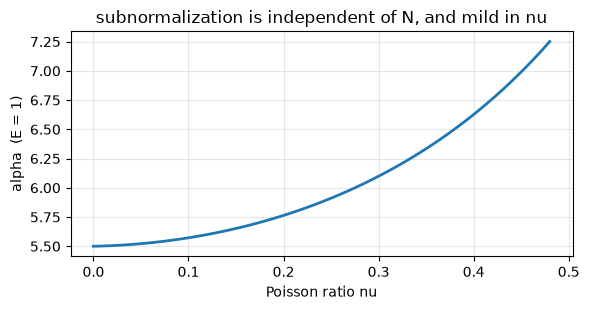

In [5]:
nus = np.linspace(0, 0.48, 60)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(nus, [(33 + n) / (6 * (1 - n**2)) for n in nus], lw=2)
ax.set_xlabel("Poisson ratio nu"); ax.set_ylabel("alpha  (E = 1)")
ax.set_title("subnormalization is independent of N, and mild in nu")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 4. Which component sits where

The three components occupy disjoint parts of the nine-point stencil:
the centre carries $I$ alone, the axis neighbours carry $I$ and $Z$, and the
diagonal neighbours carry $I$ and $X$. Counting by position recovers the
total, $17 = 1 + 4\cdot 2 + 4\cdot 2$.

In [6]:
pos = defaultdict(set)
off = {"I": 0, "Sc": +1, "Sc'": -1}
for (p, q, s), c in t17.items():
    pos[(off[p], off[q])].add(s)

print(f"{'offset':>10}  components")
for k in sorted(pos):
    kind = ("centre" if k == (0, 0) else
            "axis" if 0 in k else "diagonal")
    print(f"{str(k):>10}  {''.join(sorted(pos[k], key='IZX'.find)):<6} {kind}")
counts = defaultdict(int)
for k, v in pos.items():
    counts["centre" if k == (0,0) else "axis" if 0 in k else "diagonal"] += len(v)
print("\ncount by position:", dict(counts), "total", sum(counts.values()))
assert sum(counts.values()) == 17

    offset  components
  (-1, -1)  IX     diagonal
   (-1, 0)  IZ     axis
   (-1, 1)  IX     diagonal
   (0, -1)  IZ     axis
    (0, 0)  I      centre
    (0, 1)  IZ     axis
   (1, -1)  IX     diagonal
    (1, 0)  IZ     axis
    (1, 1)  IX     diagonal

count by position: {'centre': 1, 'axis': 8, 'diagonal': 8} total 17


## 5. Essential conditions: $17 \to 49$

One term with no shift stays as it is; eight carry a shift in one direction and
split in two; eight carry shifts in both and split in four:
$1 + 8\cdot2 + 8\cdot4 = 49$. Every split halves a coefficient into equal
magnitudes, so $\alpha$ does not move.

We verify against a direct plane-stress $Q_4$ assembly, restricted to the
unconstrained nodes.

In [7]:
def q4_assemble(N, nu, E=1.0, h=1.0, periodic=False):
    """Direct plane-stress Q4 assembly, 2x2 Gauss."""
    D = E/(1-nu**2) * np.array([[1, nu, 0], [nu, 1, 0], [0, 0, (1-nu)/2]])
    g = 1/np.sqrt(3); gps = [(-g,-g), (g,-g), (g,g), (-g,g)]
    Ke = np.zeros((8, 8))
    for xi, eta in gps:
        dN = np.array([[-(1-eta), (1-eta), (1+eta), -(1+eta)],
                       [-(1-xi), -(1+xi), (1+xi), (1-xi)]]) / 4.0
        J = h/2.0; dNxy = dN / J
        B = np.zeros((3, 8))
        for a in range(4):
            B[0, 2*a] = dNxy[0, a]; B[1, 2*a+1] = dNxy[1, a]
            B[2, 2*a] = dNxy[1, a]; B[2, 2*a+1] = dNxy[0, a]
        Ke += B.T @ D @ B * (J * J)
    K = np.zeros((2*N*N, 2*N*N)); offs = [(0,0), (1,0), (1,1), (0,1)]
    rng = range(N) if periodic else range(N-1)
    for ix in rng:
        for iy in rng:
            gd = []
            for dx, dy in offs:
                base = 2 * (((ix+dx) % N) * N + ((iy+dy) % N)); gd += [base, base+1]
            K[np.ix_(gd, gd)] += Ke
    return K

nu = 0.3
t49 = elasticity(nu)
print(f"essential: L = {len(t49)}, alpha = {alpha(t49):.4f}, "
      f"components = {comps(t49)}")
assert len(t49) == 49 and abs(alpha(t49) - alpha(t17)) < 1e-12

free_n = [j for j in range(N) if j not in (0, N-1)]
idx = np.array([2*(a*N+b)+d for a in free_n for b in free_n for d in (0, 1)])
ii = np.ix_(idx, idx)
T = q4_assemble(N, nu)
print("vs direct Q4, restricted to interior nodes:",
      np.abs(dense(t49)[ii] - T[ii]).max())
assert np.abs(dense(t49)[ii] - T[ii]).max() < 1e-12

essential: L = 49, alpha = 6.0989, components = IZX
vs direct Q4, restricted to interior nodes: 8.326672684688674e-17


## 6. Traction-free: the shear block loses its symmetry

Here is the subtlety the paper spends most of Section 6.3 on.

On a periodic grid $\mathbf{A}$ is antisymmetric, so the two Kronecker products
in $\mathbf{K}_{xy}$ collapse onto one and the block comes out **symmetric**.
The rewriting $\mathbf{K}_{xy}\otimes X$ presumes exactly that.

The traction-free corrections are diagonal, and they destroy the antisymmetry.
$\mathbf{K}_{xy}$ is then no longer symmetric, $X$ alone cannot carry it, and a
fourth component $iY$ appears.

In [8]:
def xy_block(t):
    A = dense(t)
    return A[0::2, 1::2]              # rows u_x, cols u_y

for nm, kw in [("periodic", dict(per=True)), ("essential", {}),
               ("traction-free", dict(xf=(1,1), yf=(1,1)))]:
    tt = elasticity(nu, **kw)
    Kxy = xy_block(tt)
    print(f"{nm:<16} K_xy symmetric? {np.allclose(Kxy, Kxy.T)!s:<6} "
          f"L={len(tt):4d}  components={comps(tt)}")

t109 = elasticity(nu, xf=(1,1), yf=(1,1))
print(f"\ntraction-free vs direct open-mesh Q4: "
      f"{np.abs(dense(t109) - q4_assemble(N, nu)).max():.2e}")
assert np.abs(dense(t109) - q4_assemble(N, nu)).max() < 1e-12
assert "iY" in comps(t109) and "iY" not in comps(t49)

periodic         K_xy symmetric? True   L=  17  components=IZX
essential        K_xy symmetric? True   L=  49  components=IZX
traction-free    K_xy symmetric? False  L= 109  components=IZXiY

traction-free vs direct open-mesh Q4: 4.44e-16


**One free direction is enough.** The $iY$ component is not a property of
"the traction-free problem" — it appears as soon as *any* direction carries a
diagonal correction. Clamping two opposite edges and freeing the other two
already needs four components.

In [9]:
for nm, xf, yf in [("all four edges clamped", (0,0), (0,0)),
                   ("left and right clamped",  (0,0), (1,1)),
                   ("left only",               (0,1), (1,1)),
                   ("none (traction-free)",    (1,1), (1,1))]:
    tt = elasticity(nu, xf=xf, yf=yf)
    print(f"{nm:<24} L={len(tt):4d}  alpha={alpha(tt):.4f}  "
          f"components={comps(tt)}")

all four edges clamped   L=  49  alpha=6.0989  components=IZX
left and right clamped   L=  75  alpha=6.1264  components=IZXiY
left only                L=  98  alpha=6.3324  components=IZXiY
none (traction-free)     L= 109  alpha=6.3324  components=IZXiY


## 7. The special value $\nu = 1/3$

The $iY$ coefficient carries $(1-3\nu)/4$, which vanishes identically at
$\nu = 1/3$. The value is not arbitrary: it is where the two contributions to
$\mathbf{K}_{xy}$ — the transverse coupling $\nu$ and the shear term
$(1-\nu)/2$ — are equal. There the traction-free shear block is symmetric
again, the fourth component disappears, and the count drops from $109$ to
$93$.

nu = 1/3 : L = 93, components = IZX


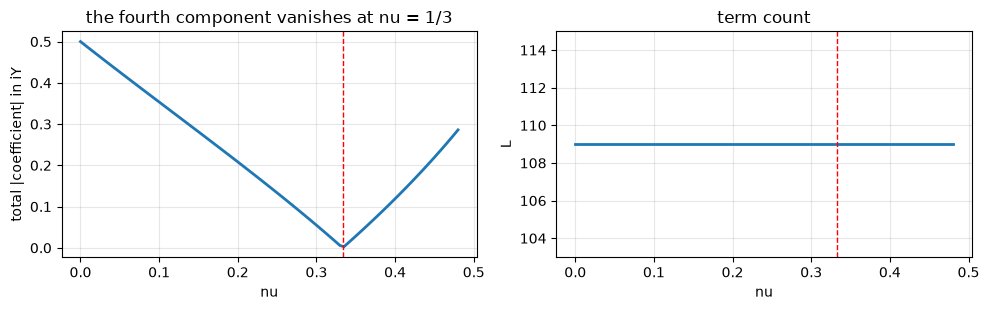

In [10]:
ns = np.linspace(0.0, 0.48, 97)
mass, Ls = [], []
for n_ in ns:
    tt = elasticity(n_, xf=(1,1), yf=(1,1))
    mass.append(sum(abs(v) for k, v in tt.items() if k[2] == "iY"))
    Ls.append(len(tt))

t13 = elasticity(1/3, xf=(1,1), yf=(1,1))
print(f"nu = 1/3 : L = {len(t13)}, components = {comps(t13)}")
assert len(t13) == 93 and "iY" not in comps(t13)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.2))
a1.plot(ns, mass, lw=2); a1.axvline(1/3, color="r", ls="--", lw=1)
a1.set_xlabel("nu"); a1.set_ylabel("total |coefficient| in iY")
a1.set_title("the fourth component vanishes at nu = 1/3"); a1.grid(alpha=.3)
a2.plot(ns, Ls, lw=2); a2.axvline(1/3, color="r", ls="--", lw=1)
a2.set_xlabel("nu"); a2.set_ylabel("L"); a2.set_title("term count")
a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Mixed conditions

Section 6.5 of the paper. Every mixed case lies between the fully clamped and
fully free encodings in both $L$ and $\alpha$, so the traction-free figures
bound the cost of any combination.

In [11]:
rows = []
for nm, xf, yf in [("all four", (0,0), (0,0)), ("left and right", (0,0), (1,1)),
                   ("left only", (0,1), (1,1)), ("none", (1,1), (1,1))]:
    tt = elasticity(nu, xf=xf, yf=yf)
    rows.append((nm, comps(tt), len(tt), alpha(tt)))
print(f"{'edges clamped':<18}{'components':<12}{'L':>5}{'alpha':>9}")
for r in rows: print(f"{r[0]:<18}{r[1]:<12}{r[2]:>5}{r[3]:>9.3f}")

Ls_ = [r[2] for r in rows]; as_ = [r[3] for r in rows]
assert Ls_ == sorted(Ls_) and as_ == sorted(as_)
print("\nBoth L and alpha increase monotonically as the boundary opens.")

edges clamped     components      L    alpha
all four          IZX            49    6.099
left and right    IZXiY          75    6.126
left only         IZXiY          98    6.332
none              IZXiY         109    6.332

Both L and alpha increase monotonically as the boundary opens.


## 9. The cantilever

Clamp the left edge, leave top and bottom traction-free, apply a uniform
traction $t$ on the right edge. The $x$-direction is de-periodized at both ends
and free at $j_x = 3$ alone; the $y$-direction is free at both ends.

The prescribed traction is a *natural* condition — it enters the load, not the
operator.

In [12]:
t_cant = elasticity(nu, xf=(False, True), yf=(True, True))
print(f"cantilever operator: L = {len(t_cant)}, alpha = {alpha(t_cant):.4f}, "
      f"components = {comps(t_cant)}")

# restrict away the clamped column j_x = 0
keep = np.array([2*(a*N+b)+d for a in range(1, N) for b in range(N) for d in (0,1)])
kk = np.ix_(keep, keep)
Kc = dense(t_cant)[kk]
print(f"restricted operator: {Kc.shape[0]} dof, symmetric? {np.allclose(Kc, Kc.T)}, "
      f"min eigenvalue = {np.linalg.eigvalsh(Kc).min():.4f}")
assert np.linalg.eigvalsh(Kc).min() > 1e-10, "clamped structure must be SPD"

# uniform traction t on the right edge, x-direction
tload = 1.0
prof = 0.5 * np.array([1.0, 2.0, 2.0, 1.0])
f = tload * np.kron(np.eye(N)[N-1], np.kron(prof, np.array([1.0, 0.0])))
u = np.linalg.solve(Kc, f[keep])
print("\ntip displacement (node (3,0)..(3,3), u_x):",
      u.reshape(N-1, N, 2)[-1, :, 0])

cantilever operator: L = 98, alpha = 6.3324, components = IZXiY
restricted operator: 24 dof, symmetric? True, min eigenvalue = 0.0234

tip displacement (node (3,0)..(3,3), u_x): [2.9627 2.9426 2.9426 2.9627]


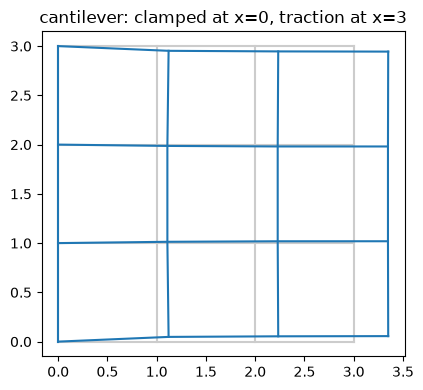

In [13]:
# draw the deformed shape
disp = np.zeros((N, N, 2))
disp.reshape(-1, 2)[N:] = u.reshape(-1, 2)
X0, Y0 = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
s = 0.35 / max(np.abs(disp).max(), 1e-12)
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(N):
    ax.plot(X0[i, :], Y0[i, :], "-", color="0.8")
    ax.plot(X0[:, i], Y0[:, i], "-", color="0.8")
Xd, Yd = X0 + s*disp[:, :, 0], Y0 + s*disp[:, :, 1]
for i in range(N):
    ax.plot(Xd[i, :], Yd[i, :], "-", color="C0")
    ax.plot(Xd[:, i], Yd[:, i], "-", color="C0")
ax.set_aspect("equal"); ax.set_title("cantilever: clamped at x=0, traction at x=3")
plt.tight_layout(); plt.show()

## 10. How tight is $\alpha$ here?

For Poisson the encoding was optimal: $\alpha = \|\mathbf{K}\|_\infty$ exactly.
Elasticity is not, and it is worth seeing why. The gap splits as

$$\frac{\alpha}{\|\mathbf{K}\|_2}
 = \frac{\alpha}{\|\mathbf{K}\|_\infty}\cdot
   \frac{\|\mathbf{K}\|_\infty}{\|\mathbf{K}\|_2},$$

the first factor belonging to the encoding and the second to the operator. The
first is $1.18$–$1.22$ here, and it shrinks as $\nu$ grows.

In [14]:
def norms(t, restrict=None):
    A = dense(t)
    if restrict is not None: A = A[np.ix_(restrict, restrict)]
    return np.linalg.norm(A, 2), np.abs(A).sum(1).max()

print(f"{'nu':>6}{'alpha':>9}{'||K||_2':>10}{'||K||_inf':>11}"
      f"{'a/inf':>8}{'a/2':>8}{'eta':>8}")
for nu_ in (0.0, 0.3, 0.45):
    tt = elasticity(nu_)
    a = alpha(tt); n2, ninf = norms(tt)
    print(f"{nu_:>6.2f}{a:>9.4f}{n2:>10.4f}{ninf:>11.4f}"
          f"{a/ninf:>8.3f}{a/n2:>8.3f}{n2/a:>8.3f}")

print("\n(N = 4 here, so ||K||_2 has not yet converged; the paper's table "
      "uses N = 32. The a/||K||_inf column is already at its limit.)")

    nu    alpha   ||K||_2  ||K||_inf   a/inf     a/2     eta
  0.00   5.5000    3.4740     4.5000   1.222   1.583   0.632
  0.30   6.0989    3.7972     5.1099   1.194   1.606   0.623
  0.45   6.9906    4.3213     5.9248   1.180   1.618   0.618

(N = 4 here, so ||K||_2 has not yet converged; the paper's table uses N = 32. The a/||K||_inf column is already at its limit.)


Where does the slack come from? $\alpha$ charges $|c_k|$ for every term. A
given row of $\mathbf{K}$ receives one entry per term — but the $I$ and $Z$
components carrying the same shift pair land on the *same* entry, and combine
as $c_I + c_Z$ for $u_x$ and $c_I - c_Z$ for $u_y$.

So on the axis neighbours the two components **add in one direction and cancel
in the other**: this is exactly the anisotropy the $Z$ component exists to
create. Where they cancel, the $\ell_1$ sum has paid for both and the operator
kept only the difference. No single row can collect every term at full
magnitude, which is why $\alpha > \|\mathbf{K}\|_\infty$ here and not for
Poisson.

In [15]:
tt = elasticity(0.3, per=True)
A  = dense(tt)
mats = {k: np.kron(U[k[0]], np.kron(U[k[1]], PAULI[k[2]])) for k in tt}

row = 2 * nid(2, 2)                                   # interior node, u_x
per_term = sum(np.abs(c * mats[k][row]).sum() for k, c in tt.items())
print(f"sum over terms of |contribution to this row| : {per_term:.4f}  (= alpha)")
print(f"actual |row| sum of the assembled operator   : {np.abs(A[row]).sum():.4f}")
print(f"ratio                                        : "
      f"{per_term / np.abs(A[row]).sum():.4f}\n")

def IZ(r, c_):
    cI = sum(v * mats[k][r, c_] for k, v in tt.items() if k[2] == "I")
    cZ = sum(v * mats[k][r, c_] for k, v in tt.items() if k[2] == "Z")
    return cI, cZ

print(f"{'neighbour':<12}{'dof':>4}{'c_I':>10}{'c_Z':>10}{'net':>10}"
      f"{'|I|+|Z|':>10}{'wasted':>9}")
waste = 0.0
for nm, (dx, dy) in [("x-neighbour", (1, 0)), ("y-neighbour", (0, 1))]:
    for d, lbl in ((0, "u_x"), (1, "u_y")):
        r  = 2 * nid(2, 2) + d
        c_ = 2 * nid((2+dx) % N, (2+dy) % N) + d
        cI, cZ = IZ(r, c_)
        w = abs(cI) + abs(cZ) - abs(cI + cZ)
        waste += w
        print(f"{nm:<12}{lbl:>4}{cI:>10.4f}{cZ:>10.4f}{cI+cZ:>10.4f}"
              f"{abs(cI)+abs(cZ):>10.4f}{w:>9.4f}")

print(f"\nAlong x the two components add; along y they cancel (or vice versa "
      f"for u_y).\nThat cancellation is invisible to the l1 sum, and it is "
      f"the whole gap.")
assert waste > 0.4

sum over terms of |contribution to this row| : 6.0989  (= alpha)
actual |row| sum of the assembled operator   : 5.1099
ratio                                        : 1.1935

neighbour    dof       c_I       c_Z       net   |I|+|Z|   wasted
x-neighbour  u_x   -0.2473   -0.3571   -0.6044    0.6044   0.0000
x-neighbour  u_y   -0.2473    0.3571    0.1099    0.6044   0.4945
y-neighbour  u_x   -0.2473    0.3571    0.1099    0.6044   0.4945
y-neighbour  u_y   -0.2473   -0.3571   -0.6044    0.6044   0.0000

Along x the two components add; along y they cancel (or vice versa for u_y).
That cancellation is invisible to the l1 sum, and it is the whole gap.


## 11. The block encoding

Same three-step recipe. The system register is $2m+1 = 5$ qubits; the essential
case needs $a = 6$ ancilla, so $\mathcal{U}$ is $2^{11} = 2048$ square. The
traction-free case takes a few seconds to assemble.

In [16]:
def prep_unitary(c, n_anc):
    d = 2 ** n_anc; v = np.zeros(d)
    v[:len(c)] = np.sqrt(np.abs(c) / np.abs(c).sum())
    M = np.eye(d); M[:, 0] = v
    Q, R = np.linalg.qr(M)
    return Q * np.sign(np.diag(R))

def block_encoding(t):
    keys = list(t); c = np.array([t[k] for k in keys]); L = len(keys)
    na = max(1, int(np.ceil(np.log2(L)))); da, ds = 2 ** na, 2 * N * N
    P = prep_unitary(c, na)
    SEL = np.zeros((da * ds, da * ds))
    for k in range(da):
        if k < L:
            p, q, s = keys[k]
            Uk = np.sign(c[k]) * np.kron(U[p], np.kron(U[q], PAULI[s]))
        else:
            Uk = np.eye(ds)
        SEL[k*ds:(k+1)*ds, k*ds:(k+1)*ds] = Uk
    PI = np.kron(P, np.eye(ds))
    return PI.T @ SEL @ PI, na, ds

for nm, kw in [("periodic", dict(per=True)), ("essential", {}),
               ("traction-free", dict(xf=(1,1), yf=(1,1)))]:
    tt = elasticity(nu, **kw)
    Ub, na, ds = block_encoding(tt)
    err  = np.abs(Ub[:ds, :ds] - dense(tt) / alpha(tt)).max()
    unit = np.abs(Ub @ Ub.T - np.eye(Ub.shape[0])).max()
    print(f"{nm:<15} L={len(tt):4d} a={na} qubits={na+2*m+1} dim={Ub.shape[0]:5d} "
          f"|top-K/alpha|={err:.1e} |UU^T-I|={unit:.1e}")
    assert err < 1e-12 and unit < 1e-12

periodic        L=  17 a=5 qubits=10 dim= 1024 |top-K/alpha|=1.1e-16 |UU^T-I|=1.4e-15
essential       L=  49 a=6 qubits=11 dim= 2048 |top-K/alpha|=3.3e-16 |UU^T-I|=3.1e-15
traction-free   L= 109 a=7 qubits=12 dim= 4096 |top-K/alpha|=9.4e-16 |UU^T-I|=4.1e-15


## 12. Exercises

1. **Kronecker rank.** Reshape $\mathbf{K}_{xy}$ by the Van Loan rearrangement
   and take singular values. Show the rank is $1$ for the periodic operator and
   $2$ once a boundary is opened — the structural reason no single product
   $\mathbf{G}^{(x)}\otimes\mathbf{G}^{(y)}$ can represent the free shear block.

2. **The $iY$ term is Hermitian.** Verify that $\mathbf{S}\otimes iY$ is real,
   unitary and symmetric when $\mathbf{S}$ is antisymmetric, which is what
   makes the fourth component legitimate in a Hermitian LCU.

3. **Sweep $\nu$ through $1/3$.** Watch the $iY$ coefficients change sign.
   What does the sign change mean physically?

4. **Three dimensions.** A DOF-qubit *triplet* replaces the single qubit, and
   the $2\times2$ block becomes $3\times3$. How many components does the
   analogue of $\{I,Z,X,iY\}$ need, and what happens to $L$?

5. **End to end.** Feed the cantilever operator and load of Section 9 to a
   QSVT-based matrix inversion and compare against the direct solve there.
   The subnormalization $\alpha$ enters the condition number the polynomial
   must handle, which is where all of this was headed.